0 2.583824396133423
200 0.007467865943908691
400 0.0033362144604325294
600 0.0024657121393829584
800 0.0033616083674132824
1000 0.0014782713260501623
1200 0.0008527524769306183
1400 0.0006117887096479535
1600 0.000636737619061023
1800 0.00025894714053720236


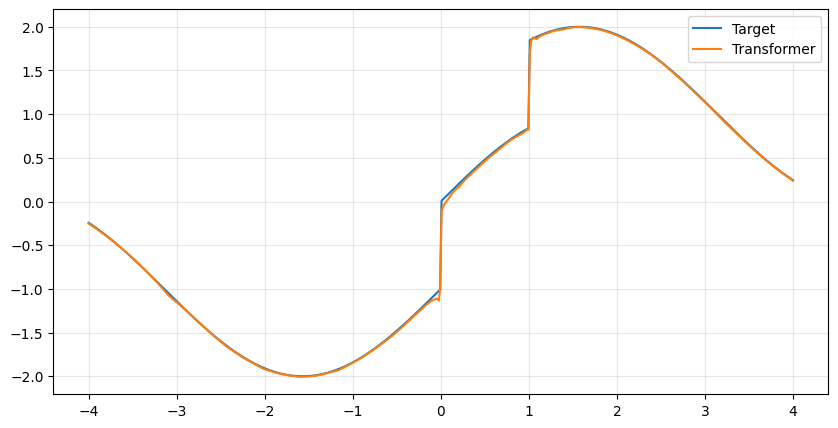

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(1)

device = "cuda" if torch.cuda.is_available() else "cpu"

def f(x):
    return torch.sin(x) + (x > 0).float() - (x < 1).float()

x = torch.linspace(-4, 4, 512, device=device).unsqueeze(0)
y = f(x)

class TransformerRegressor(nn.Module):
    def __init__(self, dimension=32, heads=4, layers=2):
        super().__init__()

        self.input = nn.Linear(1, dimension)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dimension,
            nhead=heads,
            dim_feedforward=64,
            dropout=0.0,
            batch_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers,
        )

        self.output = nn.Linear(dimension, 1)

    def forward(self, x):
        x = self.input(x.unsqueeze(-1))
        x = self.encoder(x)
        return self.output(x).squeeze(-1)

model = TransformerRegressor().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_function = nn.MSELoss()

for epoch in range(2000):
    model.train()

    prediction = model(x)
    loss = loss_function(prediction, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(epoch, loss.item())

model.eval()

with torch.no_grad():
    prediction = model(x)

plt.figure(figsize=(10, 5))
plt.plot(x.squeeze().cpu(), y.squeeze().cpu(), label="Target")
plt.plot(x.squeeze().cpu(), prediction.squeeze().cpu(), label="Transformer")
plt.legend()
plt.grid(alpha=0.3)
plt.show()